In [36]:
import numpy as np
from scipy import stats
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import pandas as pd

#Matrices en NumPy

matriz = array 2D de números organizados en filas y columnas, útil para estructurar y procesar datos.



Uso en análisis de datos: Permite organizar encuestas o experimentos y calcular estadísticas rápidamente como media, suma, máximo y mínimo.

In [2]:
# Creating a matrix
matrix_A = np.array([[1, 2], [3, 4]])

# Reshaping a matrix
reshaped_matrix = matrix_A.reshape(4,1)

# Changing values in a matrix
matrix_A[0,0] = 5
print("Updated Matrix A:\n", matrix_A)

Updated Matrix A:
 [[5 2]
 [3 4]]


In [3]:
# Example survey data matrix (5 respondents, 4 questions)
# each row represents an individual’s responses to a survey and each column a different question.

# Encuestas: calcular promedios, totales y valores máximo/mínimo por pregunta o por participante

survey_data = np.array([[5, 1, 4, 4],
                        [4, 2, 4, 3],
                        [5, 1, 1, 5],
                        [3, 2, 1, 2],
                        [2, 1, 2, 5]])

# Calculating various statistics
average_responses = np.mean(survey_data, axis=0)   #general trend or satisfaction level for each question.
total_responses = np.sum(survey_data, axis=0)     #overall engagement or interest in each question.
max_responses = np.max(survey_data, axis=0)   #range of responses, indicating areas of strong opinions.
min_responses = np.min(survey_data, axis=0)

print("Average Responses:", average_responses)
print("Total Responses:", total_responses)
print("Maximum Responses:", max_responses)
print("Minimum Responses:", min_responses)

Average Responses: [3.8 1.4 2.4 3.8]
Total Responses: [19  7 12 19]
Maximum Responses: [5 2 4 5]
Minimum Responses: [2 1 1 2]


In [10]:
# Movie ratings matrix (5 viewers, 3 movies)

#Calificaciones de películas: promedio por película y preferencia máxima de cada espectador.

movie_ratings = np.array([
    [5, 1, 4],
    [4, 4, 2],
    [4, 3, 5],
    [1, 1, 5],
    [3, 2, 1]
])

average_rating = np.mean(movie_ratings, axis=0)   # → calcula el promedio de cada columna, es decir, de cada película.
print("Average Rating per movie:", average_rating)

# 2️⃣ Viewer preference: highest-rated movie for each viewer (row-wise argmax)
viewer_preferences = np.argmax(movie_ratings, axis=1)  # → devuelve la columna con la puntuación máxima de cada fila, es decir, la película favorita de cada espectador.
print("Viewer preference (movie index 0=Movie1, 1=Movie2, 2=Movie3):", viewer_preferences)


Average Rating per movie: [3.4 2.2 3.4]
Viewer preference (movie index 0=Movie1, 1=Movie2, 2=Movie3): [0 0 2 2 0]


Operaciones con matrices (básicas)

In [11]:
# suma = np.add(B, C)
# resta = np.subtract(B, C)
# producto = np.dot(B, C)

# Define two matrices
matrix_B = np.array([[2, 3], [4, 5]])
matrix_C = np.array([[1, 1], [1, 1]])

# : suma, resta y multiplicación
sum_matrix = np.add(matrix_B, matrix_C)
diff_matrix = np.subtract(matrix_B, matrix_C)
product_matrix  = np.dot(matrix_B, matrix_C)

print("Sum of Matrices:\n", sum_matrix)
print("Difference of Matrices:\n", diff_matrix)
print("Product of Matrices:\n", product_matrix )

Sum of Matrices:
 [[3 4]
 [5 6]]
Difference of Matrices:
 [[1 2]
 [3 4]]
Product of Matrices:
 [[5 5]
 [9 9]]


In [15]:
# Aplicaciones reales

# Análisis económico: Precio × Cantidad → ventas totales.

price_matrix = np.array([[10, 15],
                         [12, 18]])
quantity_matrix = np.array([[30, 40],
                            [25, 35]])

total_sales_matrix = np.dot(price_matrix, quantity_matrix.T)

print("Total Sales Matrix:\n", total_sales_matrix)

print()

# Análisis de clima:Temperaturas por ciudad y día, calculando promedio, máximo, mínimo y comparando días específicos.

# Temperature data matrix (4 cities, 7 days)
temperature_data = np.array([
    [27, 20, 15, 18, 26, 18, 22],
    [24, 18, 20, 17, 19, 22, 21],
    [23, 23, 27, 25, 16, 21, 22],
    [22, 29, 23, 16, 20, 24, 28]
])

# 1️⃣ Average temperature per city (row-wise mean)
avg_temp = temperature_data.mean(axis=1).round(1)
print("Average temperature per city:", avg_temp)

# 2️⃣ Maximum and minimum temperature per city (row-wise max/min).
# axis=1 → calcula por fila, es decir, por ciudad.

max_temp = temperature_data.max(axis=1)
min_temp = temperature_data.min(axis=1)
print("Maximum temperature per city:", max_temp)
print("Minimum temperature per city:", min_temp)

# 3️⃣ Day comparison: temperature difference between Day 1 and Day 7 for each city
day1 = temperature_data[:, 0]
day7 = temperature_data[:, -1]
day_diff = day7 - day1
print("Temperature change from Day 1 to Day 7 per city:", day_diff)


Total Sales Matrix:
 [[ 900  775]
 [1080  930]]

Average temperature per city: [20.9 20.1 22.4 23.1]
Maximum temperature per city: [27 24 27 29]
Minimum temperature per city: [15 17 16 16]
Temperature change from Day 1 to Day 7 per city: [-5 -3 -1  6]


# Funciones estadísticas avanzadas

1️⃣ Pruebas de hipótesis (Hypothesis Testing)

Método para decidir si una hipótesis sobre una población es plausible usando datos muestrales.

H0 (nula): hipótesis inicial (ej. promedio = 15 min).

H1 (alternativa): hipótesis a probar (ej. promedio > 15 min).

Pasos:

Definir H0 y H1.

Elegir nivel de significancia (α, usual 0.05).

Calcular estadístico de prueba y p-valor.

Comparar p-valor con α para aceptar o rechazar H0.

Uso: ciencia, economía, medicina, investigación en general.


In [20]:

# H₀: el promedio real = 15 minutos
# H₁: el promedio real ≠ 15 minutos (o >15 si fuera prueba unilateral)

# Sample data (engagement time in minutes)
sample_data = np.array([14, 16, 15, 13, 17, 19])  # Example data

# Performing a one-sample t-test
t_statistic, p_value = stats.ttest_1samp(sample_data, 15)    # (data, popmean)

# Interpreting the result
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Fail to reject the null hypothesis


2️⃣ Varianza (Variance)

Mide la dispersión de los datos respecto a la media.

Indica riesgo, consistencia y variabilidad.

Ejemplo: inversión con rendimientos anuales, calcular varianza para evaluar riesgo.

In [17]:
# Annual returns of the investment
returns = np.array([0.08, 0.12, -0.05, 0.10, 0.07])

# Calculating variance
variance = np.var(returns)
print("Variance of the investment returns:", variance)

Variance of the investment returns: 0.003544


3️⃣ Asimetría y curtosis (Skewness & Kurtosis)

Skewness (asimetría): indica si la distribución tiene cola a la derecha (positiva) o izquierda (negativa).

Kurtosis (curtosis): indica qué tan “picuda” o “plana” es la distribución.

Alta kurtosis → valores concentrados cerca de la media, pocos extremos.

Baja kurtosis → distribución más plana, más variabilidad.

Aplicación: analizar forma y extremidades de la distribución de datos.

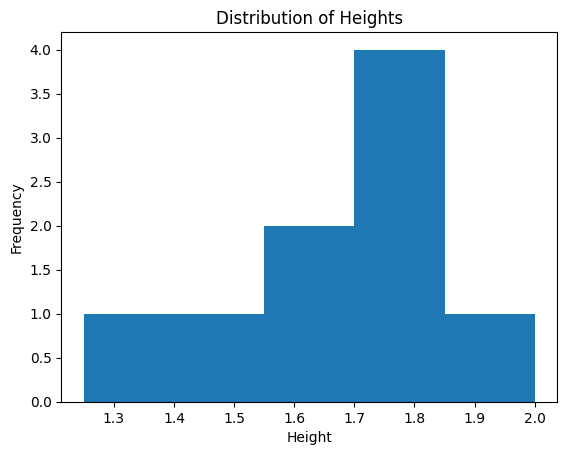

Skewness: -0.5495652643738957
Kurtosis: -0.29165980095070587


In [24]:
# Example dataset (heights in cm)
heights = np.array([1.8, 1.75, 1.25, 1.55, 1.75, 1.69, 2.00, 1.45, 1.78])  # Example data


plt.figure()
plt.hist(heights, bins=5)
plt.title("Distribution of Heights")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

# Calculating skewness and kurtosis
skewness = skew(heights)
kurtosis_value = kurtosis(heights)

print("Skewness:", skewness) # < 0 → cola a la izq
print("Kurtosis:", kurtosis_value) # < 0 -->  distribución más plana, más variabilidad.

4️⃣ Ejemplo: Evaluación de Salud y Nutrición

Una organización analiza la estatura de hombres adultos para evaluar el impacto de un programa de nutrición infantil, comparando participantes del programa con un grupo de control.

Skewness (asimetría):

* Positiva: más personas con estaturas mayores a la media → el programa podría haber mejorado el crecimiento.

* Negativa: más personas con estaturas menores a la media → posible desnutrición o bajo impacto del programa.

Kurtosis (curtosis):

* Alta (leptocúrtica): estaturas concentradas cerca de la media → efecto consistente del programa.

* Baja (platicúrtica): distribución más dispersa → resultados de crecimiento variables entre individuos.

Aplicación:

Ayuda a evaluar la efectividad del programa.

Permite diseñar políticas públicas y programas nutricionales más efectivos.

Facilita identificar grupos que necesitan intervenciones adicionales.






5️⃣ Distribuciones de probabilidad

NumPy permite simular distribuciones (ej. normal) para modelado estadístico y pruebas de hipótesis.

Ejemplo: generar y graficar 1000 muestras de distribución normal.

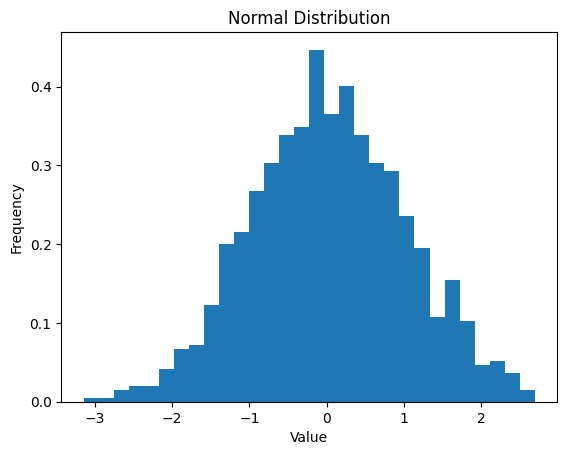

In [25]:
# Generate a normal distribution
mean = 0
std_dev = 1
samples = np.random.normal(mean, std_dev, 1000)

# Plotting the distribution
plt.hist(samples, bins=30, density=True)
plt.title("Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

6️⃣ Muestreo estadístico (Sampling)

Muestreo aleatorio: seleccionar subconjuntos de datos de forma aleatoria.

Reordenamiento (shuffling): mezclar datos aleatoriamente.

In [27]:
# Random sampling from an array
data = np.arange(10)
sample = np.random.choice(data, size=5, replace=False)  #significa sin repetición.
print("Random Sample:", sample)

# Solo devuelve una parte del dataset.
# No modifica el array original.
# Se usa cuando quieres trabajar con una muestra de datos.


# Shuffling data
np.random.shuffle(data)
print("Shuffled Data:", data)

# Mezcla el orden de todos los elementos.
# No elimina ni selecciona elementos.
# Usa todos los datos.
# Modifica el array original.


Random Sample: [3 4 8 6 0]
Shuffled Data: [5 4 7 0 1 9 3 2 8 6]


7️⃣ Estadísticas descriptivas

NumPy y SciPy permiten calcular:

Media, mediana

Varianza

Skewness y kurtosis

Útil para resumir tendencia central, dispersión y forma de la distribución

In [28]:
# Variance
variance = np.var(sample)
print("Variance:", variance)

# Skewness and Kurtosis require scipy
print("Skewness:", skew(sample))
print("Kurtosis:", kurtosis(sample))

Variance: 7.359999999999999
Skewness: -0.15144853105041078
Kurtosis: -1.0348534971644607


8️⃣ Ejercicios : Muestrear y reordenar un dataset.

Calcular estadísticas descriptivas (media, mediana, varianza, skewness, kurtosis) en un dataset generado aleatoriamente.

Random Sample: [ 0 17 15  1  8  5 11  3]
Shuffled Sample: [ 5 15  3 11  0  8  1 17]
Mean: 10.02781325600797
Median: 9.945706253146186
Variance: 4.275355979972897
Skewness: 0.24001648289888172
Kurtosis: 0.1137594066937413


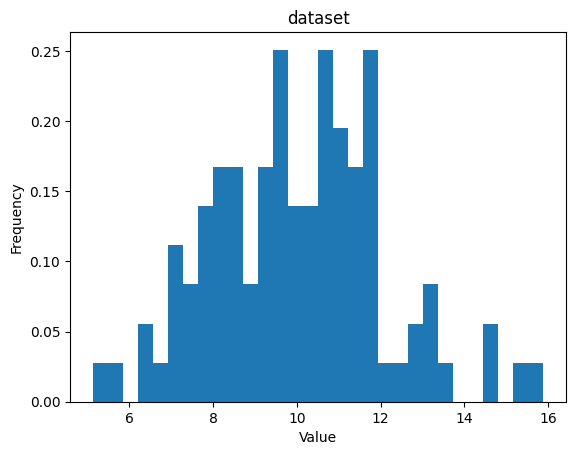

In [32]:
np.random.seed(42)

# 1️⃣ Sampling y Shuffling

# Dataset original
data = np.arange(20)

# Random sampling (tomar 8 valores sin repetición)
sample = np.random.choice(data, size=8, replace=False)
print("Random Sample:", sample)

# Shuffling del sample
np.random.shuffle(sample)
print("Shuffled Sample:", sample)


# 2️⃣ Descriptive Statistics

# Generate random dataset
dataset = np.random.normal(10, 2, 100)

# Descriptive statistics
mean_value = np.mean(dataset)
median_value = np.median(dataset)
variance_value = np.var(dataset)
skewness_value = skew(dataset)
kurtosis_value = kurtosis(dataset)

print("Mean:", mean_value)
print("Median:", median_value)
print("Variance:", variance_value)
print("Skewness:", skewness_value)
print("Kurtosis:", kurtosis_value)


# Plotting the distribution
plt.hist(dataset, bins=30, density=True)
plt.title("dataset")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

# NumPy for Time Series Data

1️⃣ Trabajo con fechas y tiempo

NumPy permite crear y manejar datos con fechas usando el tipo datetime64.

- Crear rangos de fechas.

- Convertir fechas a diferentes formatos.

útil para trabajar con datos que cambian en el tiempo (clima, ventas, actividad de usuarios, etc.).

In [33]:
# Creating date ranges
dates = np.arange('2020-01', '2020-02', dtype='datetime64[D]')
print("January 2020 Dates:\n", dates)

January 2020 Dates:
 ['2020-01-01' '2020-01-02' '2020-01-03' '2020-01-04' '2020-01-05'
 '2020-01-06' '2020-01-07' '2020-01-08' '2020-01-09' '2020-01-10'
 '2020-01-11' '2020-01-12' '2020-01-13' '2020-01-14' '2020-01-15'
 '2020-01-16' '2020-01-17' '2020-01-18' '2020-01-19' '2020-01-20'
 '2020-01-21' '2020-01-22' '2020-01-23' '2020-01-24' '2020-01-25'
 '2020-01-26' '2020-01-27' '2020-01-28' '2020-01-29' '2020-01-30'
 '2020-01-31']


In [34]:
# Converting dates to a different format
formatted_dates = np.datetime_as_string(dates, unit='D')
print("Formatted Dates:\n", formatted_dates)

Formatted Dates:
 ['2020-01-01' '2020-01-02' '2020-01-03' '2020-01-04' '2020-01-05'
 '2020-01-06' '2020-01-07' '2020-01-08' '2020-01-09' '2020-01-10'
 '2020-01-11' '2020-01-12' '2020-01-13' '2020-01-14' '2020-01-15'
 '2020-01-16' '2020-01-17' '2020-01-18' '2020-01-19' '2020-01-20'
 '2020-01-21' '2020-01-22' '2020-01-23' '2020-01-24' '2020-01-25'
 '2020-01-26' '2020-01-27' '2020-01-28' '2020-01-29' '2020-01-30'
 '2020-01-31']


2️⃣ Análisis básico de series temporales

busca identificar: Tendencias | Patrones | Estacionalidad

NumPy suele combinarse con Pandas, que facilita trabajar con datos indexados por fecha.


📈 ventas diarias
🌡 temperatura diaria
📊 precio de acciones




3️⃣ Rolling Statistics

Las estadísticas móviles (rolling) calculan métricas dentro de una ventana de tiempo: media móvil, desviación estándar móvil

Sirven para suavizar los datos y detectar tendencias.


4️⃣ Window Functions

Las window functions aplican cálculos dentro de una ventana de datos: suma, promedio, funciones personalizadas

Son más generales que las rolling statistics.

5️⃣ Forecasting básico

Para predecir valores futuros se pueden usar métodos simples como:

**Simple Moving Average (SMA)**
Promedio de los últimos valores dentro de una ventana.

Se usa para suavizar la serie y estimar tendencias futuras.

Rolling Mean:
 2026-03-08 16:44:34.941815         NaN
2026-03-09 16:44:34.941815         NaN
2026-03-10 16:44:34.941815         NaN
2026-03-11 16:44:34.941815         NaN
2026-03-12 16:44:34.941815   -0.461078
                                ...   
2026-06-11 16:44:34.941815    0.425358
2026-06-12 16:44:34.941815    0.526516
2026-06-13 16:44:34.941815    0.921239
2026-06-14 16:44:34.941815    0.797027
2026-06-15 16:44:34.941815    0.894348
Freq: D, Length: 100, dtype: float64
Window Sum:
 2026-03-08 16:44:34.941815         NaN
2026-03-09 16:44:34.941815         NaN
2026-03-10 16:44:34.941815         NaN
2026-03-11 16:44:34.941815         NaN
2026-03-12 16:44:34.941815   -2.305389
                                ...   
2026-06-11 16:44:34.941815    2.126789
2026-06-12 16:44:34.941815    2.632579
2026-06-13 16:44:34.941815    4.606195
2026-06-14 16:44:34.941815    3.985135
2026-06-15 16:44:34.941815    4.471739
Freq: D, Length: 100, dtype: float64


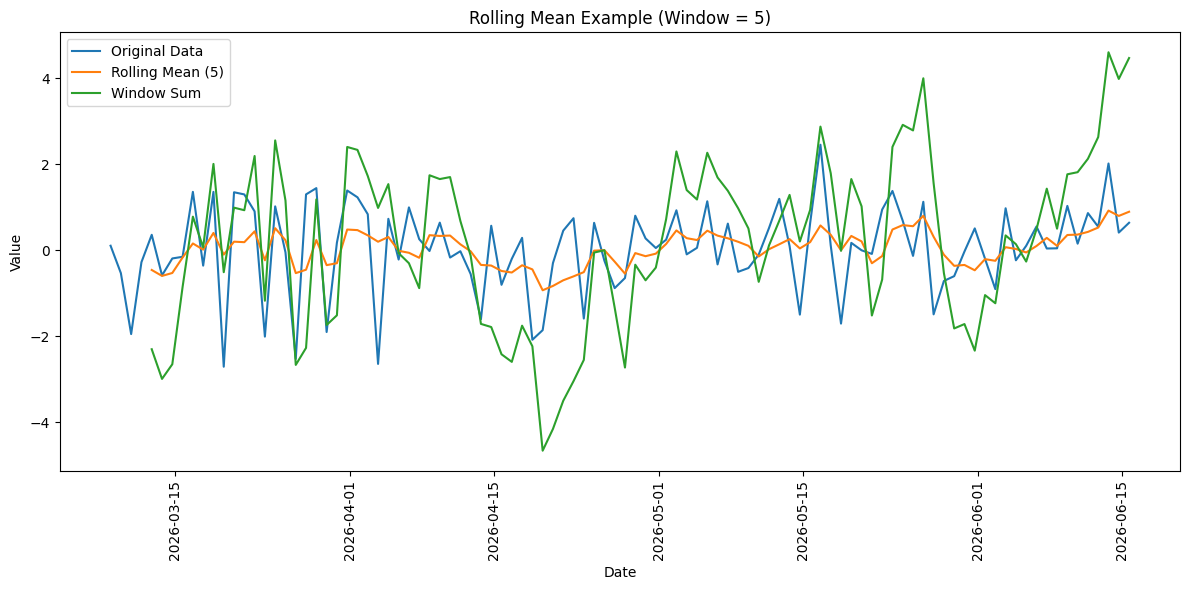

In [44]:
#100 números aleatorios con distribución normal + 100 fechas consecutivas empezando hoy + Crear una serie temporal
ts_data = pd.Series(np.random.randn(100), index=pd.date_range('today', periods=100))

# Example: Using rolling statistics
rolling_mean = ts_data.rolling(window=5).mean()    # calcula una media móvil de 5 días.
print("Rolling Mean:\n", rolling_mean)

# # Calculating simple moving average = es lo mismo que rolling statistics
# sma = ts_data.rolling(window=5).mean()
# print("Simple Moving Average:\n", sma)

# Example: Applying a window function
window_sum = ts_data.rolling(window=5).sum()   # calcula la suma de los últimos 5 valores.
print("Window Sum:\n", window_sum)


#grafico
plt.figure(figsize=(12,6))
plt.plot(ts_data.index, ts_data.values, label="Original Data")
plt.plot(rolling_mean.index, rolling_mean.values, label="Rolling Mean (5)")
# plt.plot(sma.index, sma.values, label="Simple Moving Average")
plt.plot(window_sum.index, window_sum.values, label="Window Sum")


plt.title("Rolling Mean Example (Window = 5)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



6️⃣ Ejercicio: Crear una serie temporal, Fechas diarias de 2022

Temperatura simulada (10–35°C)

Humedad simulada (30–90%)

Análisis de datos

Calcular media, mediana y desviación estándar

Encontrar el día con mayor temperatura y mayor humedad

graficar tendencias

Window functions

Calcular media móvil de 7 días

comparar datos originales vs promedio móvil en un gráfico

            Temperature   Humidity
Date                              
2022-01-01    19.363503  53.166158
2022-01-02    33.767858  87.671434
2022-01-03    28.299849  84.321039
2022-01-04    24.966462  41.747468
2022-01-05    13.900466  34.161678

Temperature stats: Mean=22.29, Median=22.78, Std=7.28
Humidity stats: Mean=59.68, Median=59.53, Std=18.04
Highest Temperature: 34.75 on 2022-09-19
Highest Humidity: 89.98 on 2022-06-16


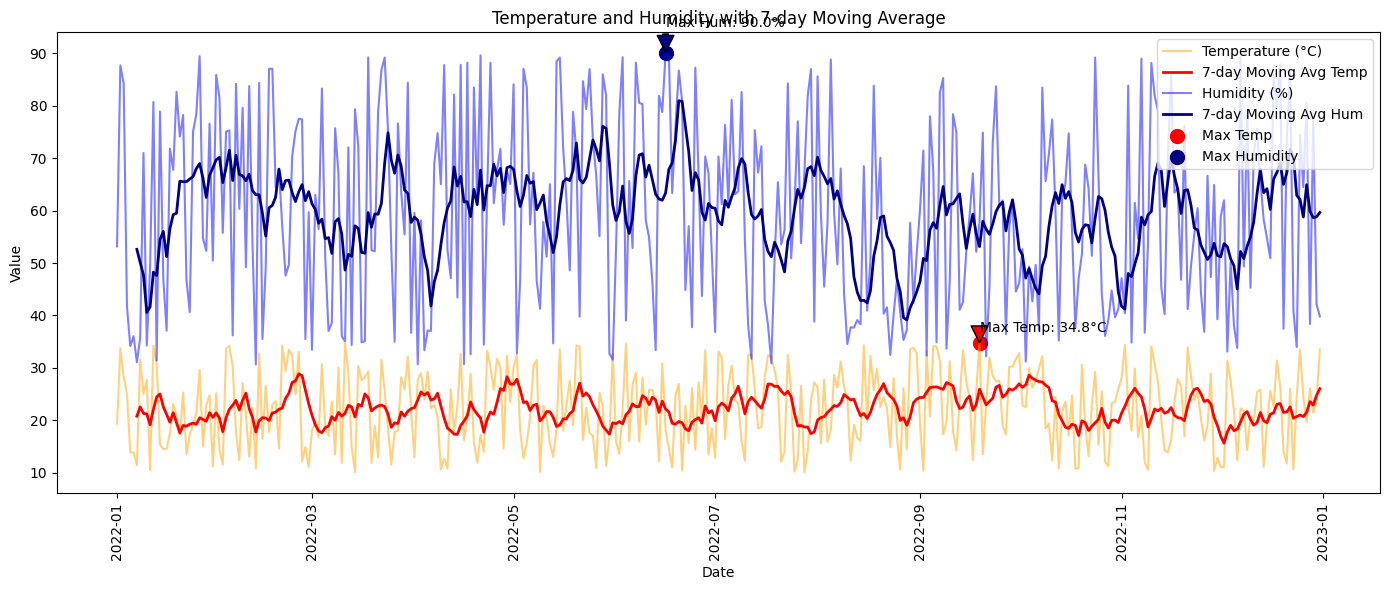

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Data Creation

# Generar rango de fechas diario para 2022
dates = pd.date_range(start='2022-01-01', end='2022-12-31', freq='D')

# Simular temperatura diaria entre 10°C y 35°C
np.random.seed(42)  # para reproducibilidad
temperature = np.random.uniform(low=10, high=35, size=len(dates))

# Simular humedad diaria entre 30% y 90%
humidity = np.random.uniform(low=30, high=90, size=len(dates))

# Crear DataFrame
df = pd.DataFrame({
    'Date': dates,
    'Temperature': temperature,
    'Humidity': humidity
})

df.set_index('Date', inplace=True)
print(df.head())

# 2️⃣ Data Analysis

# Estadísticas básicas
temp_mean = df['Temperature'].mean()
temp_median = df['Temperature'].median()
temp_std = df['Temperature'].std()

hum_mean = df['Humidity'].mean()
hum_median = df['Humidity'].median()
hum_std = df['Humidity'].std()

print("\nTemperature stats: Mean={:.2f}, Median={:.2f}, Std={:.2f}".format(temp_mean, temp_median, temp_std))
print("Humidity stats: Mean={:.2f}, Median={:.2f}, Std={:.2f}".format(hum_mean, hum_median, hum_std))

# Fecha con mayor temperatura y mayor humedad
max_temp_date = df['Temperature'].idxmax()
max_hum_date = df['Humidity'].idxmax()

print(f"Highest Temperature: {df['Temperature'].max():.2f} on {max_temp_date.date()}")
print(f"Highest Humidity: {df['Humidity'].max():.2f} on {max_hum_date.date()}")


# 3️⃣ Window Function

# Calcular media móvil de 7 días
df['Temp_7day_avg'] = df['Temperature'].rolling(window=7).mean()
df['Hum_7day_avg'] = df['Humidity'].rolling(window=7).mean()

# Graficar original vs media móvil
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Temperature'], label='Temperature (°C)', color='orange', alpha=0.5)
plt.plot(df.index, df['Temp_7day_avg'], label='7-day Moving Avg Temp', color='red', linewidth=2)
plt.plot(df.index, df['Humidity'], label='Humidity (%)', color='blue', alpha=0.5)
plt.plot(df.index, df['Hum_7day_avg'], label='7-day Moving Avg Hum', color='navy', linewidth=2)


# Marcar la temperatura máxima
plt.scatter(max_temp_date, df.loc[max_temp_date, 'Temperature'], color='red', s=100, label='Max Temp')
plt.annotate(f"Max Temp: {df.loc[max_temp_date, 'Temperature']:.1f}°C",
             xy=(max_temp_date, df.loc[max_temp_date, 'Temperature']),
             xytext=(max_temp_date, df['Temperature'].max()+2),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=10)

# Marcar la humedad máxima
plt.scatter(max_hum_date, df.loc[max_hum_date, 'Humidity'], color='navy', s=100, label='Max Humidity')
plt.annotate(f"Max Hum: {df.loc[max_hum_date, 'Humidity']:.1f}%",
             xy=(max_hum_date, df.loc[max_hum_date, 'Humidity']),
             xytext=(max_hum_date, df['Humidity'].max()+5),
             arrowprops=dict(facecolor='navy', shrink=0.05),
             fontsize=10)

plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Temperature and Humidity with 7-day Moving Average')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Integrating NumPy, Pandas & Matplotlib

Manipulación de datos: NumPy + Pandas permite filtrar y calcular estadísticas rápidamente en grandes datasets.

Generación de datos: NumPy crea datos aleatorios para análisis en DataFrames.

Visualizaciones: Matplotlib facilita gráficos personalizados (scatter, líneas, complejos).

Conclusión: La combinación de NumPy, Pandas y Matplotlib optimiza el análisis y la visualización de grandes volúmenes de datos.

In [48]:
import numpy as np
import pandas as pd
import time

# Creating a large DataFrame
data = pd.DataFrame(np.random.rand(100000, 4), columns=['A', 'B', 'C', 'D'])

# Timing Pandas operations
start_time = time.time()
result_pandas = data[(data['A'] > 0.5) & (data['B'] < 0.5)].mean()
end_time = time.time()
print("Pandas Conditional Mean:\n", result_pandas)
print("Pandas Operation Time: {:.5f} seconds".format(end_time - start_time))

# Timing equivalent NumPy operations
numpy_data = data.to_numpy()
start_time = time.time()
result_numpy = np.mean(numpy_data[(numpy_data[:, 0] > 0.5) & (numpy_data[:, 1] < 0.5)], axis=0)
end_time = time.time()
print("NumPy Conditional Mean:\n", result_numpy)
print("NumPy Operation Time: {:.5f} seconds".format(end_time - start_time))  #tardo la mitad

Pandas Conditional Mean:
 A    0.749156
B    0.248865
C    0.502006
D    0.497165
dtype: float64
Pandas Operation Time: 0.00700 seconds
NumPy Conditional Mean:
 [0.74915562 0.24886469 0.50200562 0.49716526]
NumPy Operation Time: 0.00355 seconds


Caso real: Análisis de temperaturas diarias globales.


Un equipo de investigadores analizó un dataset con temperaturas diarias de varias ciudades del mundo durante la última década, incluyendo fecha, ciudad, temperatura y condiciones climáticas, buscando patrones de cambio de temperatura y su relación con el clima.

**Pasos del análisis:**

* Carga de datos: Se importaron a un DataFrame de Pandas para facilitar manipulación y análisis.

* Limpieza de datos: Se trataron valores faltantes y se filtró información irrelevante.

* Análisis estadístico: Con NumPy calcularon media, mediana y desviación estándar de las temperaturas.

* Análisis condicional: Se aislaron datos según condiciones climáticas y ciudades específicas.

* Visualización: Matplotlib permitió graficar la evolución temporal de las temperaturas y la relación con el clima.

**Conclusiones:**

* Se observó un claro aumento de temperaturas en la mayoría de las ciudades.

* Condiciones como alta humedad se asociaron con temperaturas más elevadas.

* Los patrones estacionales de temperatura fueron evidentes en las visualizaciones.


